In [1]:
import pickle as pkl

import corner
import matplotlib.pyplot as plt
import numpy as np
from getdist import MCSamples, plots
from pyoperators import MPI
from qubic.lib.Qfoldertools import  create_folder_if_not_exists
from qubic.lib.Qmpi_tools import MpiTools

hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


In [2]:
mcmc_file = pkl.load(open("parametric_d0_DB_test_noise/Fit/test/mcmc.pkl", "rb"))
print(mcmc_file.keys())

dict_keys(['samples', 'samples_flat', 'parameters', 'fit_parameters'])


In [3]:
mcmc_file["parameters"]

{'save_iter': 1,
 'foldername': 'test_noise',
 'filename': 'test',
 'lastite': True,
 'CMB': {'cmb': True, 'seed': 1, 'r': 0, 'Alens': 1},
 'Foregrounds': {'fit_spectral_index': False,
  'bin_mixing_matrix': 4,
  'blind_method': 'minimize',
  'Dust': {'Dust_in': True,
   'Dust_out': True,
   'type': 'parametric',
   'model': 'd0',
   'beta_init': [1.54, 0.0, 10000000],
   'nside_beta_in': 0,
   'nside_beta_out': 0,
   'nu0': 150.0,
   'l_corr': 10000000,
   'amplification': 1},
  'Synchrotron': {'Synchrotron_in': False,
   'Synchrotron_out': False,
   'type': 'blind',
   'model': 's0',
   'beta_init': [-3, 0],
   'nu0': 150,
   'amplification': 1},
  'CO': {'CO_in': False,
   'CO_out': False,
   'nu0': 230.538,
   'polarization_fraction': 0.01}},
 'QUBIC': {'instrument': 'DB',
  'configuration': 'FI',
  'npointings': 8000,
  'nsub_in': 12,
  'nsub_out': 12,
  'convolution_in': True,
  'convolution_out': False,
  'preconditioner': False,
  'NOISE': {'ndet': 1,
   'npho150': 1,
   'npho2

# Parameters

In [4]:
samples = mcmc_file["samples"]
samples_flat = mcmc_file["samples_flat"]
parameters = mcmc_file["parameters"]
fit_params = mcmc_file["fit_parameters"]

fit_parameters_names = ["r", "Ad", "alphad"]

print("samples", samples.shape)
print("samples_flat", samples_flat.shape)

samples (300, 50, 3)
samples_flat (650, 3)


In [5]:
comm = MPI.COMM_WORLD
mpi = MpiTools(comm)

### Folder where spectrum should be stored
folder = fit_params["simulation_path"]
folder_spectrum = folder + "/Spectrum/"
folder_save = folder + "/Fit/" + fit_params["name"] + "/"
create_folder_if_not_exists(comm, folder_save)

### Import Spectrum parameters
# TODO: should we really modify these values
nbins = fit_params["Spectrum"]["nbins"]
sample_variance = fit_params["Spectrum"]["sample_variance"]
diagonal = fit_params["Spectrum"]["diagonal"]
dl = parameters["Spectrum"]["dl"]

### Import MCMC parameters

discard = fit_params["MCMC"]["discard"]
nwalkers = fit_params["MCMC"]["nwalkers"]
nsteps = fit_params["MCMC"]["nsteps"]
verbose = fit_params["MCMC"]["verbose"]

# MCMC

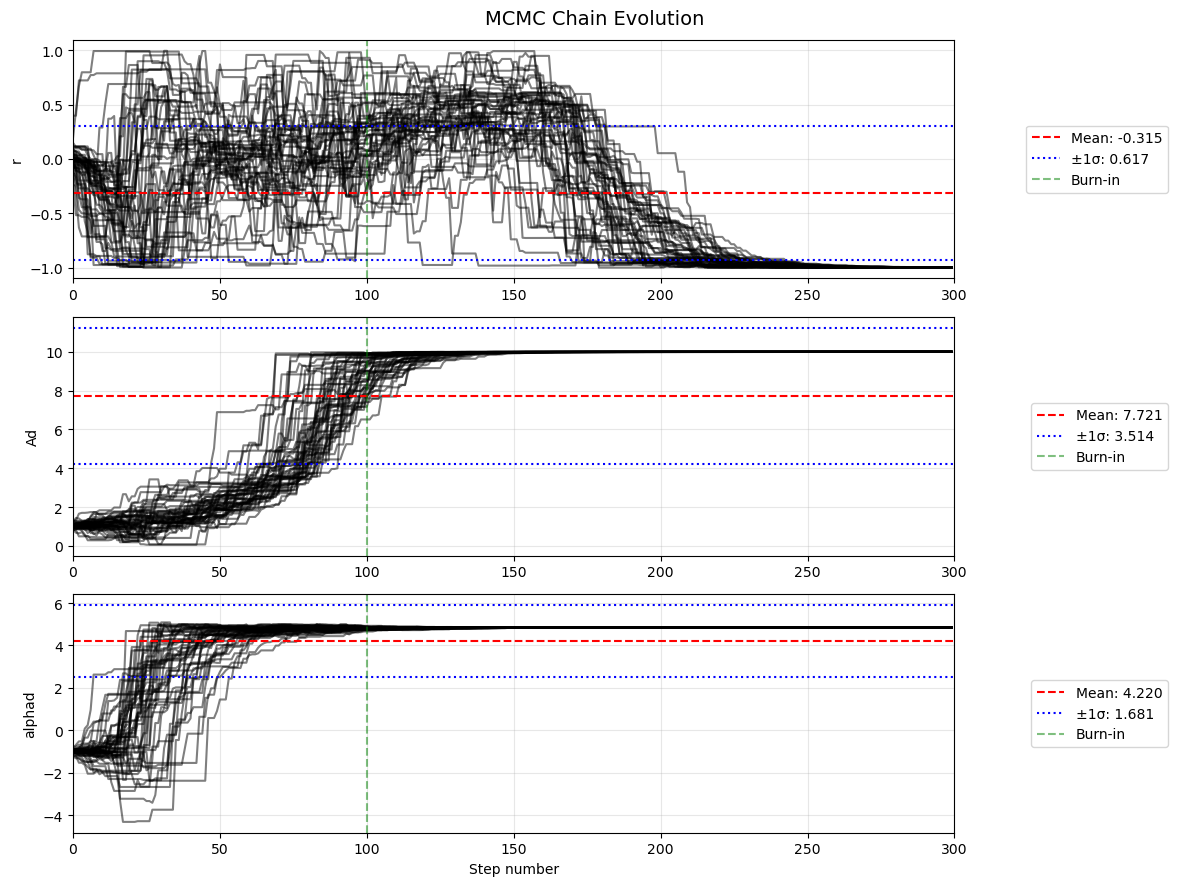

In [6]:
n_params = samples.shape[-1]

# Handle case: 1 parameter → axes is a single object
fig, axes = plt.subplots(
    n_params, 1, figsize=(12, 3 * n_params)
)

if n_params == 1:
    axes = [axes]  # wrap in list for uniform iteration

fig.suptitle("MCMC Chain Evolution", fontsize=14)

for iparam, ax in enumerate(axes):
    # Plot all walkers
    for walker in range(nwalkers):
        ax.plot(samples[:, walker, iparam], alpha=0.5, color="k")

    # Compute stats
    mean = np.mean(samples[..., iparam])
    std  = np.std(samples[..., iparam])

    # Mean and ±1σ lines
    ax.axhline(mean, color="r", linestyle="--", label=f"Mean: {mean:.3f}")
    ax.axhline(mean + std, color="b", linestyle=":", label=f"±1σ: {std:.3f}")
    ax.axhline(mean - std, color="b", linestyle=":")

    # Burn-in line
    if discard > 0:
        ax.axvline(discard, color="g", linestyle="--", alpha=0.5, label="Burn-in")

    # Labels & formatting
    ax.set_ylabel(fit_parameters_names[iparam])
    ax.set_xlim(0, nsteps)
    ax.grid(True, alpha=0.3)

    # Put legend outside
    ax.legend(loc="right", bbox_to_anchor=(1.25, 0.5))

    if iparam == n_params - 1:
        ax.set_xlabel("Step number")

plt.tight_layout()
plt.show()

# Triangle Plots

In [7]:
### Triangle Plots
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
n_params = len(fit_parameters_names)

## Corner

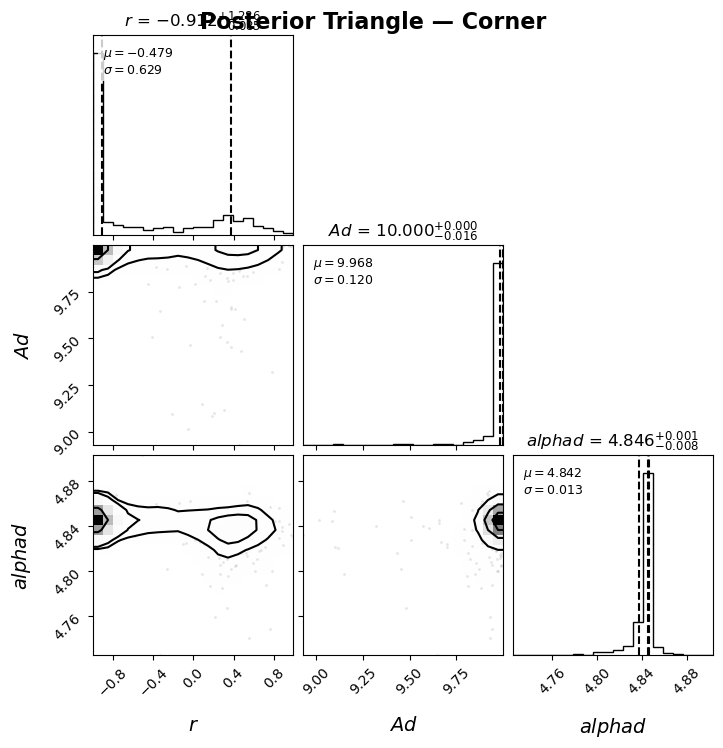

In [8]:
if n_params == 1:
    # Corner cannot do a triangle with one param → do 1D posterior
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(111)
    ax.hist(samples_flat[:, 0], bins=40, density=True, alpha=0.6)
    ax.axvline(means[0], linestyle="--", lw=1.5)
    ax.axvline(means[0] - stds[0], linestyle=":", lw=1)
    ax.axvline(means[0] + stds[0], linestyle=":", lw=1)
    ax.set_xlabel(fit_parameters_names[0])
    ax.set_ylabel("Density")
    ax.text(0.05, 0.95, rf"$\mu={means[0]:.3f}$"+"\n"+rf"$\sigma={stds[0]:.3f}$",
            transform=ax.transAxes, ha="left", va="top", bbox=dict(facecolor="white", alpha=0.8))
    fig.suptitle("Posterior — Corner (1D)", fontsize=16, fontweight="bold", y=1.01)
else:
    corner_kwargs = dict(
        labels=[rf"${p}$" for p in fit_parameters_names],
        show_titles=True,
        title_fmt=".3f",
        quantiles=[0.16, 0.5, 0.84],
        title_kwargs={"fontsize": 12},
        label_kwargs={"fontsize": 14},
        color="black",
        hist_kwargs={"density": True, "lw": 1.5},
        smooth=1.0,
    )

    fig = corner.corner(samples_flat, **corner_kwargs)
    fig.suptitle("Posterior Triangle — Corner", fontsize=16, fontweight="bold")

    axes = np.array(fig.axes).reshape(n_params, n_params)
    for i, (mean, std) in enumerate(zip(means, stds)):
        ax = axes[i, i]
        txt = rf"$\mu = {mean:.3f}$" + "\n" + rf"$\sigma = {std:.3f}$"
        ax.text(0.05, 0.95, txt,
                transform=ax.transAxes, ha="left", va="top",
                fontsize=9, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
plt.show()

## GetDist

Removed no burn in


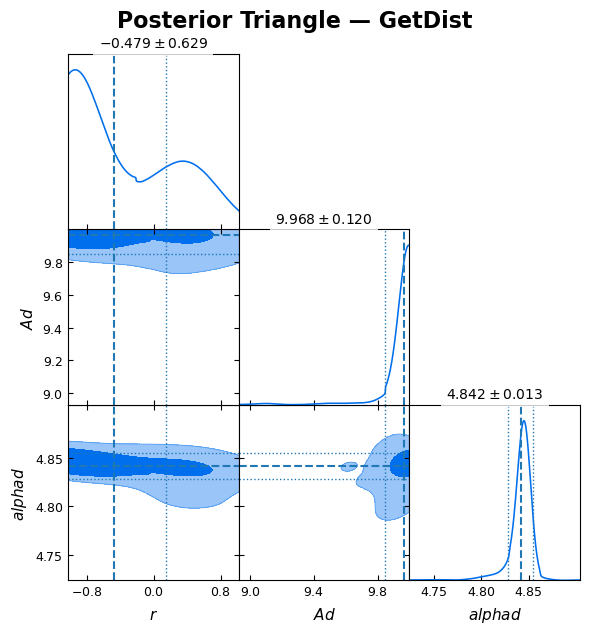

In [9]:
gds_samples = MCSamples(
    samples=samples_flat,
    names=fit_parameters_names,
    labels=[p.replace("_", r"\_") for p in fit_parameters_names],
    settings={"smooth_scale_1D": 0.5, "smooth_scale_2D": 0.6,
              "mult_bias_correction_order": 0},
)

g = plots.get_single_plotter() if n_params == 1 else plots.get_subplot_plotter()

if n_params == 1:
    g.plot_1d(gds_samples, fit_parameters_names[0], filled=True)
    ax = g.fig.axes[0]
    ax.axvline(means[0], linestyle="--", lw=1.5)
    ax.axvline(means[0] - stds[0], linestyle=":", lw=1)
    ax.axvline(means[0] + stds[0], linestyle=":", lw=1)
    ax.text(0.5, 1.0, rf"${means[0]:.3f} \pm {stds[0]:.3f}$",
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=12)
    plt.suptitle("Posterior — GetDist", fontsize=16, fontweight="bold", y=1.05)

else:
    g.settings.num_plot_contours = 2
    g.settings.alpha_filled_add = 0.6
    g.settings.linewidth = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 12
    g.settings.axes_labelsize = 14
    g.settings.legend_fontsize = 12
    g.settings.title_limit_fontsize = 12

    g.triangle_plot(gds_samples, params=fit_parameters_names, filled=True)

    axes = g.subplots
    for i in range(n_params):
        for j in range(i + 1):
            ax = axes[i, j]
            if i == j:
                ax.axvline(means[j], linestyle="--", lw=1.5)
                ax.axvline(means[j] - stds[j], linestyle=":", lw=1)
                ax.axvline(means[j] + stds[j], linestyle=":", lw=1)
                ax.text(0.5, 1.02, rf"${means[j]:.3f} \pm {stds[j]:.3f}$",
                        transform=ax.transAxes, ha="center", va="bottom",
                        fontsize=10, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
            else:
                ax.axhline(means[i], linestyle="--", lw=1.5)
                ax.axhline(means[i] - stds[i], linestyle=":", lw=1)
                ax.axhline(means[i] + stds[i], linestyle=":", lw=1)
                ax.axvline(means[j], linestyle="--", lw=1.5)
                ax.axvline(means[j] - stds[j], linestyle=":", lw=1)
                ax.axvline(means[j] + stds[j], linestyle=":", lw=1)

    plt.suptitle("Posterior Triangle — GetDist", fontsize=16, fontweight="bold", y=1.05)
plt.show()

# Test with Spectra

In [10]:
# import spectra
from qubic.lib.Qfoldertools import MergeAllFiles


files = MergeAllFiles("../" + folder_spectrum)

ell = files._reads_one_file(0, "ell")
dl = files._reads_one_file(0, "delta_ell")
fsky = files._reads_one_file(0, "fsky")

BBnoise = files._reads_all_files("Nls")
BBsignal = np.mean(files._reads_all_files("Dls", verbose=verbose), axis=0)

print(ell.shape)
print(ell)
print(BBnoise.shape)
print(BBsignal.shape)

(16,)
[ 46.5  76.5 106.5 136.5 166.5 196.5 226.5 256.5 286.5 316.5 346.5 376.5
 406.5 436.5 466.5 496.5]
(27, 2, 2, 16)
(2, 2, 16)


In [11]:
# Spectra model

from qubic.lib.MapMaking.FrequencyMapMaking.Qspectra_component import SkySpectra

sky =  SkySpectra(ell, np.array([150, 150]), comp=np.array(["CMB", "Dust"]))

r = means[0]
Alens = fit_params["cmb"]["Alens"]["fit"]
Ad = means[1]
alphad = means[2]
betad = fit_params["dust"]["betad"]["fit"]
As = fit_params["synchrotron"]["As"]["fit"]
alphas = fit_params["synchrotron"]["alphas"]["fit"]
betas = fit_params["synchrotron"]["betas"]["fit"]
eps = 0

model = sky.modelCMM(r, Alens, Ad, alphad, betad, As, alphas, betas, eps)
print(model.shape)

(2, 2, 16)


In [12]:
from qubic.lib.Qfit import FitEllSpace

fit = FitEllSpace(ell, BBsignal, BBnoise, model=sky.modelCMM, parameters_file=fit_params, sample_variance=True, fsky=fsky, dl=dl, diagonal=False)

cov = fit.noise_covariance_matrix

BBerr = np.sqrt(np.diag(cov)).reshape((3, 16))
BBerr = np.append(BBerr, BBerr[1]).reshape(BBsignal.shape)
print(BBerr.shape)

(2, 2, 16)


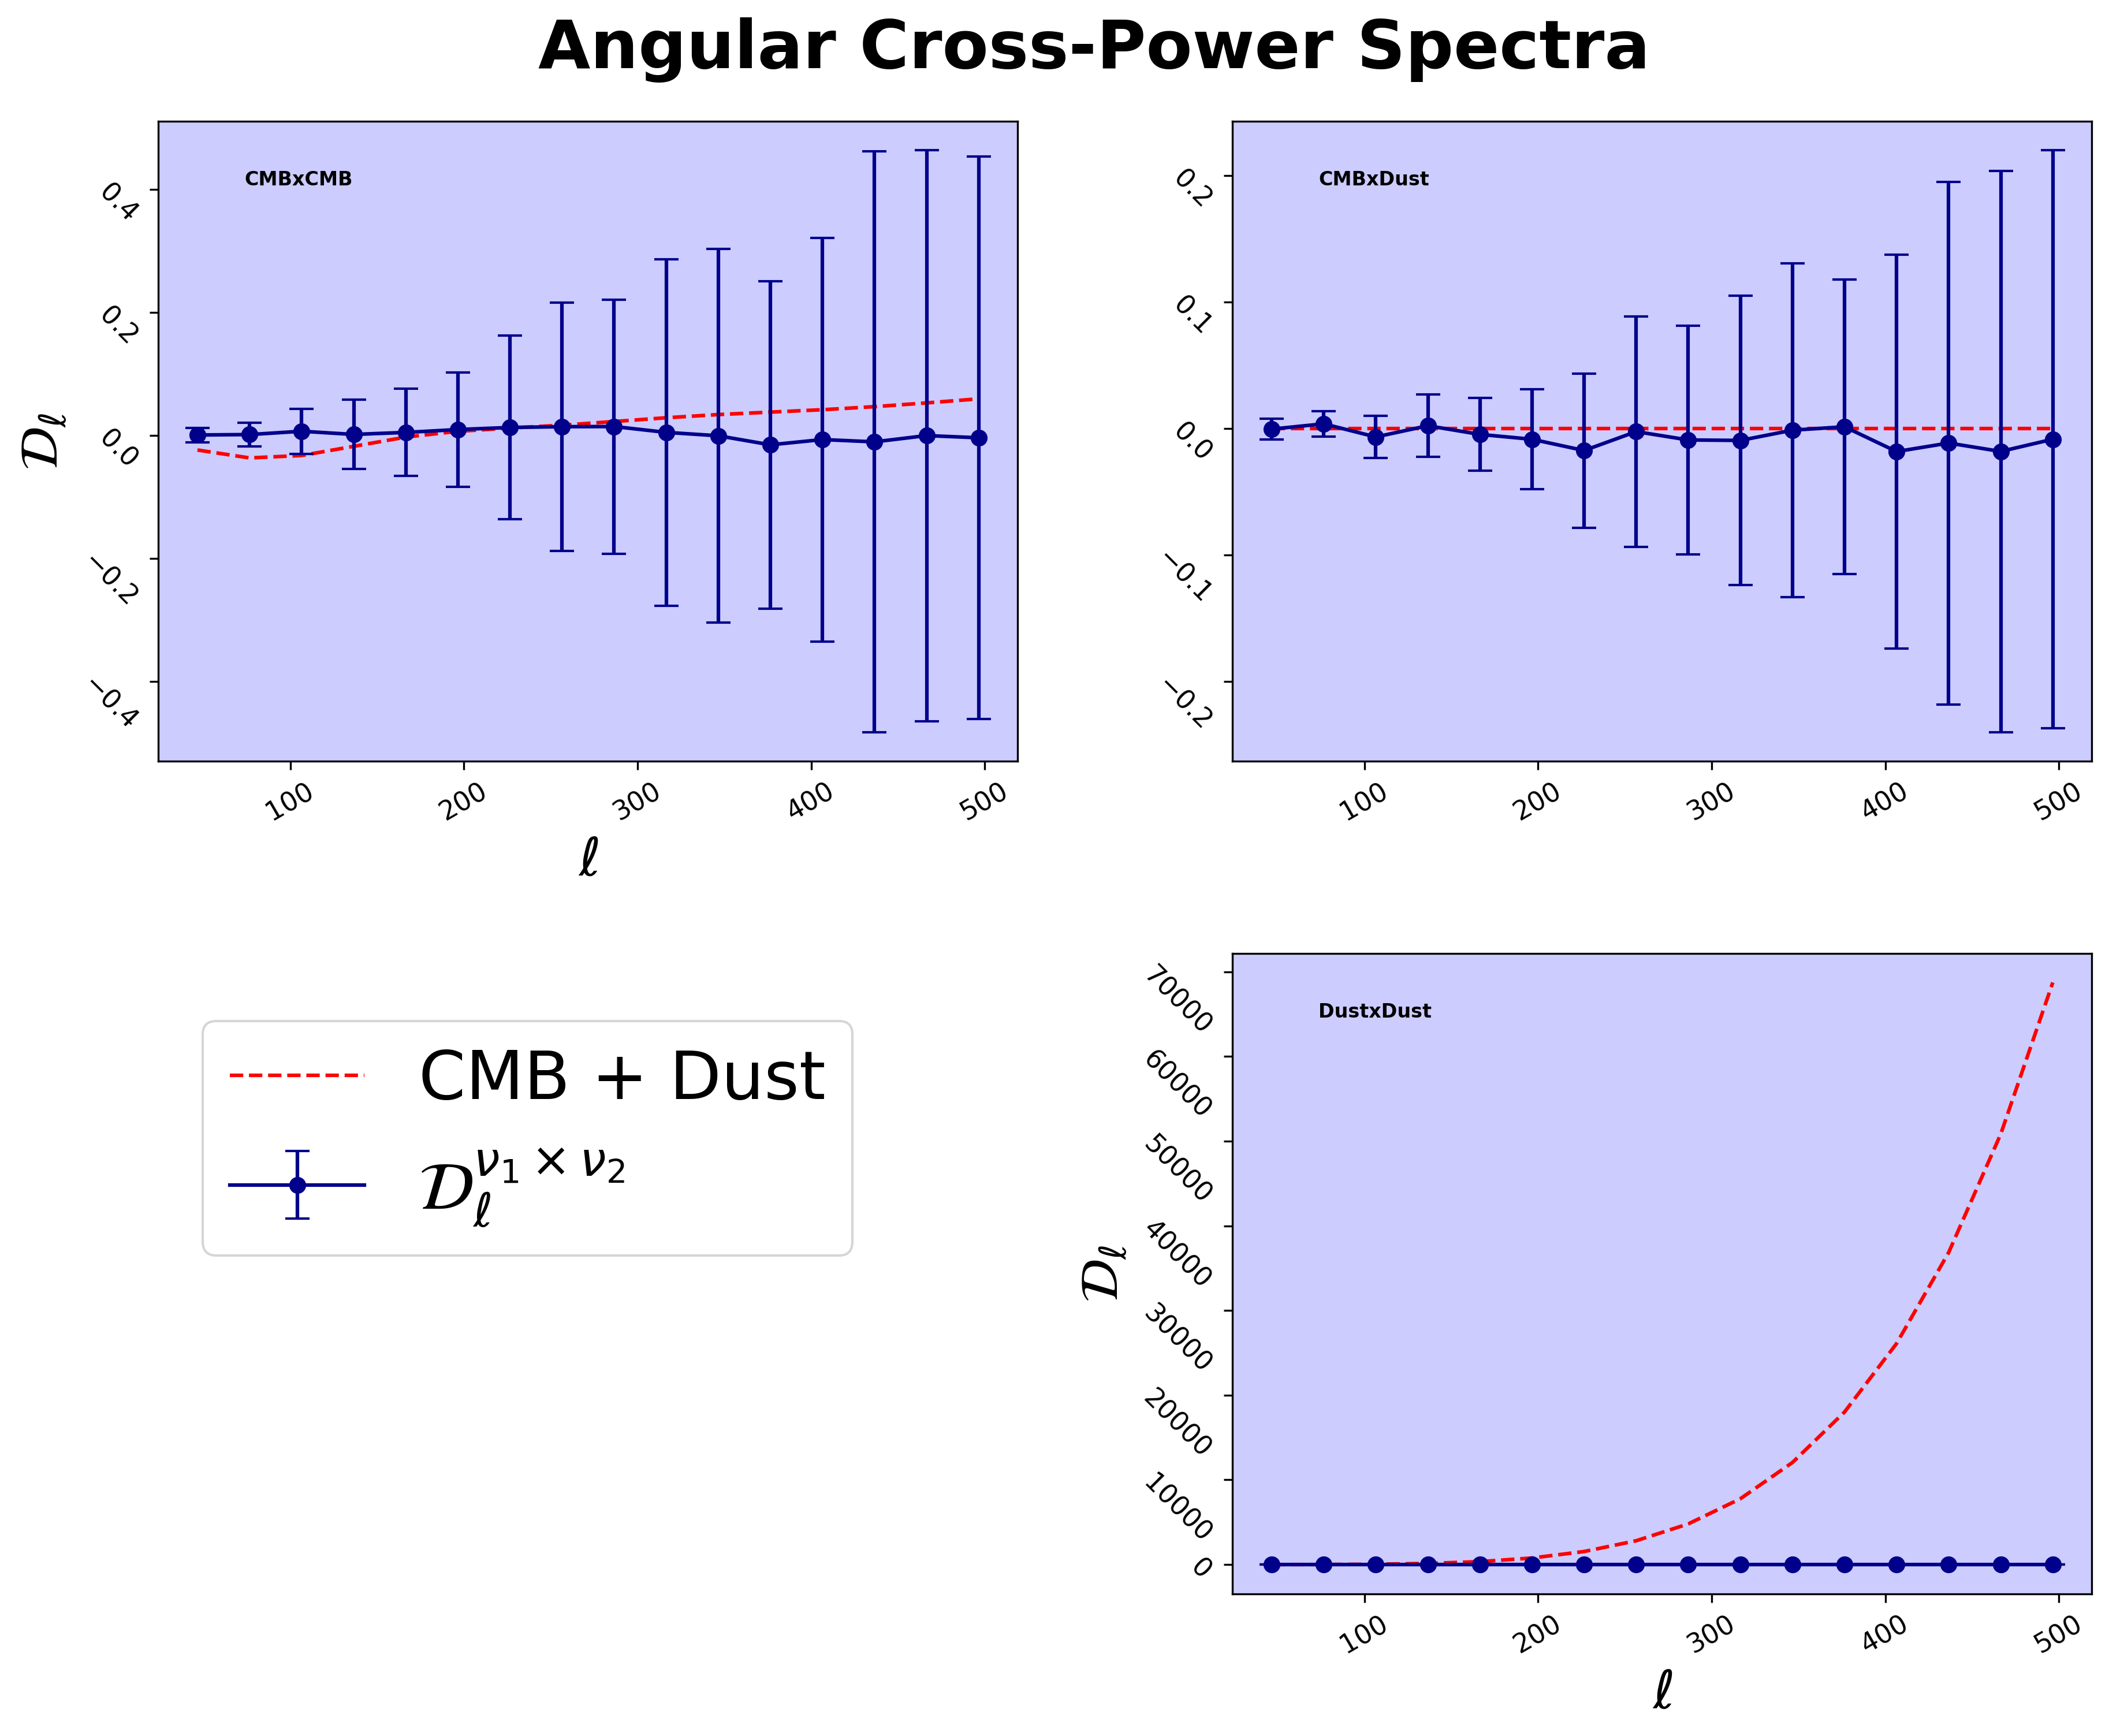

In [19]:
# Plot Spectra
from qubic.lib.MapMaking.Qmap_plotter import plot_cross_spectrum

plot_cross_spectrum(
    nus=["CMB", "Dust"],
    ell=ell,
    Dl=BBsignal- BBnoise.mean(axis=0),
    Dl_err=BBerr,
    ymodel=model,
    # Dl2=BBsignal - BBnoise.mean(axis=0),
    # Dl2_err=BBerr,
    mode="Dl",
    nrec=2,
    figsize=(12, 10),
    title="",
)

In [14]:
from matplotlib.gridspec import GridSpec
from qubic.lib.MapMaking.Qmap_plotter import Cl2BK, Dl2Cl

def _get_Dl_plot(nus, ell, Dl, Dl_err, ymodel, Dl2=None, Dl2_err=None, ymodel2=None, label_model=f'r + Dust + noise', nbins=8, nrec=2, mode='Dl', ft_nus=10, figsize=(10, 8), name=None):
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(len(nus), len(nus), figure=fig)

    k1=0
    kp=0
    for i in range(len(nus)):
        for j in range(i, len(nus)):
            ax = fig.add_subplot(gs[i, j])
            
            if i == 0 and j == 0:
                if mode == 'Dl':
                    ax.set_ylabel(r'$\mathcal{D}_{\ell}$', fontsize=20)
                else:
                    ax.set_ylabel(r'100 $ \frac{\ell \mathcal{C}_{\ell}}{2 \pi}$', fontsize=20)
            ax.set_xlabel(r'$\ell$', fontsize=25)
            
            if kp ==0:
                if mode == 'Dl':
                    if ymodel is not None:
                        ax.plot(ell[:nbins], ymodel[i, j, :nbins], '--r', label=label_model)
                    if ymodel2 is not None:
                        ax.plot(ell[:nbins], ymodel2[i, j, :nbins], '--k')
                else:
                    if ymodel is not None:
                        ax.plot(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], ymodel[i, j, :nbins])), '--r', label=label_model)
                    if ymodel2 is not None:
                        ax.plot(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], ymodel2[i, j, :nbins])), '--k')
                
                
            else:
                if mode == 'Dl':
                    if ymodel is not None:
                        ax.plot(ell[:nbins], ymodel[i, j, :nbins], '--r')
                    if ymodel2 is not None:
                        ax.plot(ell[:nbins], ymodel2[i, j, :nbins], '--k')
                else:
                    if ymodel is not None:
                        ax.plot(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], ymodel[i, j, :nbins])), '--r')
                    if ymodel2 is not None:
                        ax.plot(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], ymodel2[i, j, :nbins])), '--k')
            
            ax.patch.set_alpha(0.2)
            
            ax.annotate(f'{nus[i]:.0f}x{nus[j]:.0f}', xy=(0.1, 0.9), fontsize=ft_nus, xycoords='axes fraction', color='black', weight="bold")
            if i < nrec and j < nrec :
                ax.set_facecolor("blue")
                if kp == 0:
                    if mode == 'Dl':
                        ax.errorbar(ell[:nbins], Dl[i, j, :nbins],
                         yerr=Dl_err[i, j, :nbins], 
                         capsize=5, color='darkblue', fmt='-o', label=r'$\mathcal{D}_{\ell}^{\nu_1 \times \nu_2}$ - Dual Bands')
                        if Dl2 is not None:
                            ax.errorbar(ell[:nbins], Dl2[i, j, :nbins],
                             yerr=Dl2_err[i, j, :nbins], 
                             capsize=5, color='orange', fmt='-o', label=r'$\mathcal{D}_{\ell}^{\nu_1 \times \nu_2}$ - Ultra Wide Band')
                    else:
                        ax.errorbar(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl[i, j, :nbins])),#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl_err[i, j, :nbins])), 
                         capsize=5, color='darkblue', fmt='-o', label=r'$\mathcal{D}_{\ell}^{\nu_1 \times \nu_2}$ - Dual Bands')
                        if Dl2 is not None:
                            ax.errorbar(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl2[i, j, :nbins])),#Dls_mean[kp] - Nl_mean[kp], 
                                yerr=Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl2_err[i, j, :nbins])), 
                                capsize=5, color='orange', fmt='-o', label=r'$\mathcal{D}_{\ell}^{\nu_1 \times \nu_2}$ - Ultra Wide Band')
                    
                else:
                    if mode == 'Dl':
                        ax.errorbar(ell[:nbins], Dl[i, j, :nbins],#Dls_mean[kp] - Nl_mean[kp], 
                             yerr=Dl_err[i, j, :nbins], 
                             capsize=5, color='darkblue', fmt='-o')
                        if Dl2 is not None:
                            ax.errorbar(ell[:nbins], Dl2[i, j, :nbins],#Dls_mean[kp] - Nl_mean[kp], 
                             yerr=Dl2_err[i, j, :nbins], 
                             capsize=5, color='orange', fmt='-o')
                    else:
                        ax.errorbar(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl[i, j, :nbins])),#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl_err[i, j, :nbins])), 
                         capsize=5, color='darkblue', fmt='-o')
                        if Dl2 is not None:
                            ax.errorbar(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl2[i, j, :nbins])),#Dls_mean[kp] - Nl_mean[kp], 
                                yerr=Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl2_err[i, j, :nbins])), 
                                capsize=5, color='orange', fmt='-o')
            elif i < nrec and j >= nrec :
                ax.set_facecolor("skyblue")
                if mode == 'Dl':
                    ax.errorbar(ell[:nbins], Dl[i, j, :nbins],#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Dl_err[i, j, :nbins], 
                         capsize=5, color='blue', fmt='-o')
                    if Dl2 is not None:
                        ax.errorbar(ell[:nbins], Dl2[i, j, :nbins],#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Dl2_err[i, j, :nbins], 
                         capsize=5, color='orange', fmt='-o')
                else:
                    ax.errorbar(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl[i, j, :nbins])),#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl_err[i, j, :nbins])), 
                         capsize=5, color='blue', fmt='-o')
                    if Dl2 is not None:
                        ax.errorbar(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl2[i, j, :nbins])),#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl2_err[i, j, :nbins])), 
                         capsize=5, color='orange', fmt='-o')
            else:
                ax.set_facecolor("green")
                if mode == 'Dl':
                    ax.errorbar(ell[:nbins], Dl[i, j, :nbins],#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Dl_err[i, j, :nbins], 
                         capsize=5, color='darkgreen', fmt='-o')
                    if Dl2 is not None:
                        ax.errorbar(ell[:nbins], Dl2[i, j, :nbins],#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Dl2_err[i, j, :nbins], 
                         capsize=5, color='darkgreen', fmt='-o')
                else:
                    ax.errorbar(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl[i, j, :nbins])),#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl_err[i, j, :nbins])), 
                         capsize=5, color='darkgreen', fmt='-o')
                    if Dl2 is not None:
                        ax.errorbar(ell[:nbins], Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl2[i, j, :nbins])),#Dls_mean[kp] - Nl_mean[kp], 
                         yerr=Cl2BK(ell[:nbins], Dl2Cl(ell[:nbins], Dl2_err[i, j, :nbins])), 
                         capsize=5, color='darkgreen', fmt='-o')
            #ax[i, j].set_title(f'{data["nus"][i]:.0f}x{data["nus"][j]:.0f}')
            kp+=1
            plt.xticks(fontsize=18)
            plt.yticks(fontsize=18)
        else:
            pass#ax.axis('off')
        k1+=1

    
    fig.legend(frameon=False, fontsize=25, bbox_to_anchor=(0.3, 0.3))
    
    #plt.tight_layout()
    if name is not None:
        plt.savefig(name, format="pdf", bbox_inches="tight")
    plt.show()

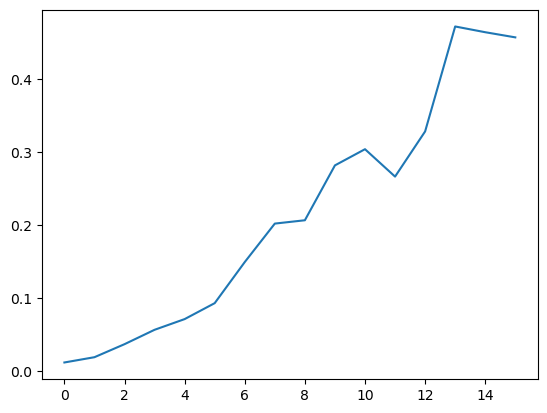

In [15]:
plt.plot(BBerr[0, 0])

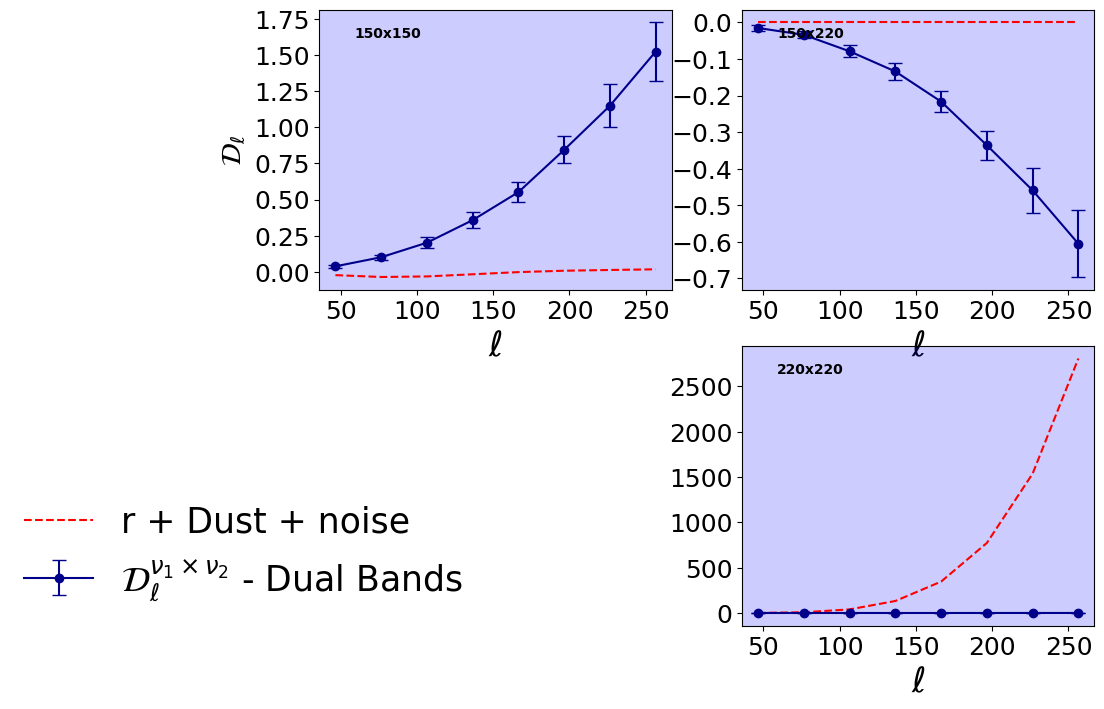

In [16]:
_get_Dl_plot(np.array([150,220]), ell, BBsignal, BBerr, model)